In [12]:
#Imports

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pickle

In [14]:
#Setting up NLP helpers

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [17]:
#Cleaning the text

def clean_text(text):
    text = re.sub(r"http\S+|www\S+|http\S+", '',str(text)) #remove links
    text = re.sub(r'\@\w+|\#', '', text) #remove @mentions and hashtags
    text = re.sub(r'[^a-zA-Z\s]', '',text) #remove anything not a letter
    text = text.lower() #lowercase
    tokens = text.split() #split into words
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words] #Lemmatize and remove stopwords
    return " ".join(tokens) #Put it backtogether


In [79]:
#Load the data 

df = pd.read_csv("chatgpt_style_reviews.csv")
df.dropna(subset=['review'],inplace=True)

In [82]:
#Creating senitement labels

if 'sentiment' not in df.columns:
    if 'rating' not in df.columns:
        raise ValueError("Dataset must have 'sentiment' or 'rating'.")
    def rating_to_sentiment(r):
        if r >= 4:
            return 'positive'
        elif r == 3:
            return 'neutral'
        else:
            return 'negative'
    df['sentiment'] = df['rating'].apply(rating_to_sentiment)    
        

In [22]:
#Apply and cleaning 

df['clean_review'] = df['review'].apply(clean_text)

In [31]:
#Balancing the dataset 

min_class_count = df['sentiment'].value_counts().min()
df_balanced = df.groupby('sentiment').sample(min_class_count, random_state=43)


In [32]:
#Vexctorize the text 

tfidf = TfidfVectorizer()
x = tfidf.fit_transform(df_balanced['clean_review']) #features
y = df_balanced['sentiment'] #lables

In [33]:
#Train test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=43)


In [34]:
#Train the model

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)


LogisticRegression(max_iter=1000)

In [35]:
#Check the model

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         3
     neutral       0.20      0.33      0.25         3
    positive       0.00      0.00      0.00         2

    accuracy                           0.12         8
   macro avg       0.07      0.11      0.08         8
weighted avg       0.08      0.12      0.09         8

Accuracy: 0.125


d:\NLP\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\NLP\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\NLP\env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [80]:
from google_play_scraper import reviews_all, Sort
import pandas as pd

#Fetch reviews
reviews = reviews_all(
    'com.openai.chatgpt',
    lang ='en',
    country = 'us',
    sort = Sort.NEWEST,
    count = 1000
)

#Create dataframe
df_scraped = pd.DataFrame(reviews)[['content', 'score', 'at']]
df_scraped.columns = ['review', 'rating', 'date']

#Map ratings to sentiments
def rating_to_sentiment(r):
    if r >= 4:
        return 'positive'
    elif r == 3:
        return 'neutral'
    else:
        return 'negative'

df_scraped['sentiment'] = df_scraped['rating'].apply(rating_to_sentiment)     

In [83]:
#Merge both datasets

df_all = pd.concat([
    df[['review', 'sentiment']],
    df_scraped[['review', 'sentiment']]
], ignore_index=True)


In [84]:
#CleanText

df_all['clean_review'] = df_all['review'].apply(clean_text)


In [43]:
#Vectorize

tfidf = TfidfVectorizer()
x = tfidf.fit_transform(df_all['clean_review'])
y = df_all['sentiment']

In [44]:
#Train test split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=43, stratify=y)

In [45]:
#Train the model 

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [46]:
#Evaluation

y_pred = model.predict(x_test)
print("\nClassification Repport:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Classification Repport:
               precision    recall  f1-score   support

    negative       0.49      0.55      0.52     20051
     neutral       0.07      0.40      0.12      9882
    positive       0.95      0.74      0.83    220557

    accuracy                           0.71    250490
   macro avg       0.50      0.56      0.49    250490
weighted avg       0.88      0.71      0.78    250490

Accuracy: 0.7082957403489161


In [49]:
pipeline = {'model': model, 'tfidf': tfidf, 'cleaner': clean_text}
with open('sentiment_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("\nModel saved as sentiment_pipeline.pkl")    


Model saved as sentiment_pipeline.pkl


In [85]:
# Save final dataset for deployment
df_all.to_csv("final_data.csv", index=False)
print("✅ final_data.csv created with sentiment column!")



✅ final_data.csv created with sentiment column!


In [51]:
import pickle

#Load saved model
with open('sentiment_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

#Ask user for a review
user_review = input("Enter a review: ")

#Clean and predict
cleaned = pipeline['cleaner'](user_review)
vectorized = pipeline['tfidf'].transform([cleaned])
prediction = pipeline['model'].predict(vectorized)[0]

print(f"Predicted Sentiment: {prediction}")

Predicted Sentiment: negative


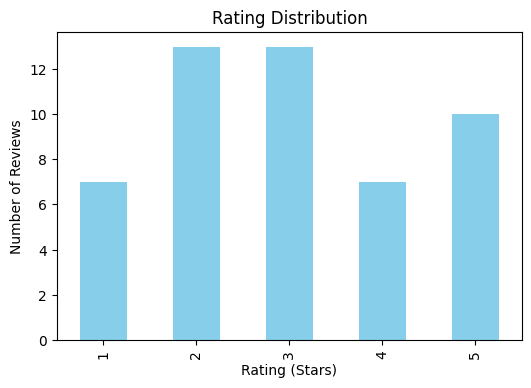

In [52]:
import matplotlib.pyplot as plt

#count each rating value
rating_counts = df['rating'].value_counts().sort_index()

#Plot the bar chart
plt.figure(figsize=(6,4))
rating_counts.plot(kind='bar', color='skyblue')
plt.title('Rating Distribution')
plt.xlabel('Rating (Stars)')
plt.ylabel("Number of Reviews")
plt.show()

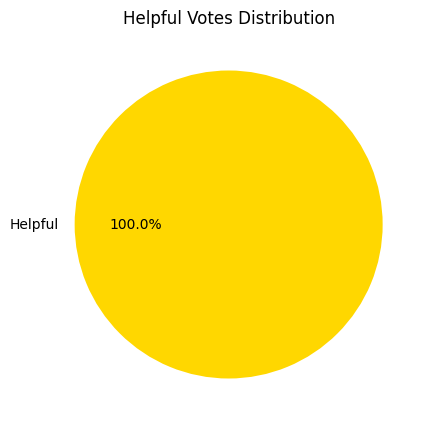

In [55]:
if 'helpful_votes' in df.columns:
    helpful_counts = df['helpful_votes'].apply(lambda x: 'Helpful' if x>0 else 'Not Helpful').value_counts()

    #Plot as a pie chart
    plt.figure(figsize=(5,5))
    helpful_counts.plot(kind='pie', autopct='%1.1f%%', colors=['gold', 'lightgray'])
    plt.title('Helpful Votes Distribution')
    plt.ylabel('')
    plt.show()
else:
    print("No 'helpful_votes' column found in data")


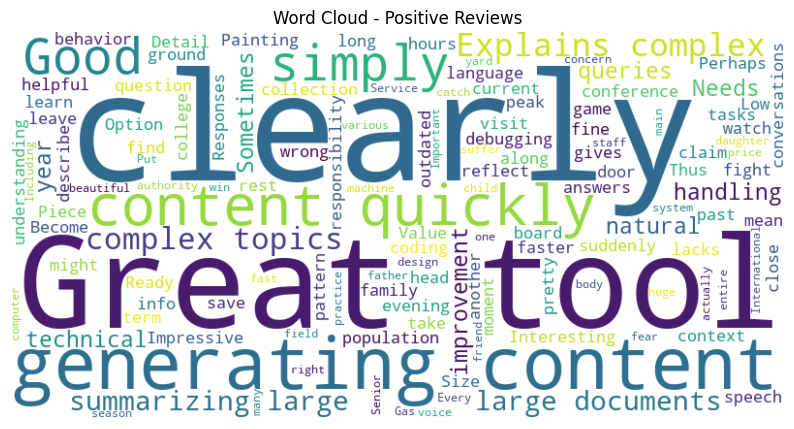

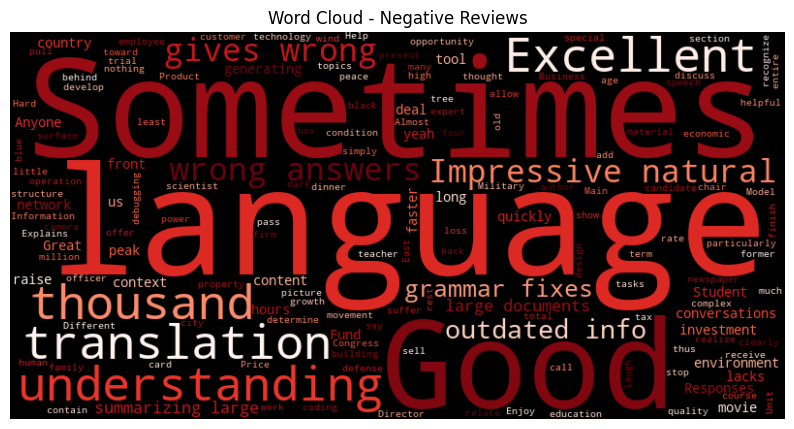

In [61]:
from wordcloud import WordCloud

#Generate positive reviews
positive_text = " ".join(df[df['sentiment'] == 'positive']['review'])
wc_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10,6))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')
plt.show()

#Generate negative reviews
negative_text = " ".join(df[df['sentiment'] == 'negative']['review'])
wc_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10,6))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews')
plt.show()


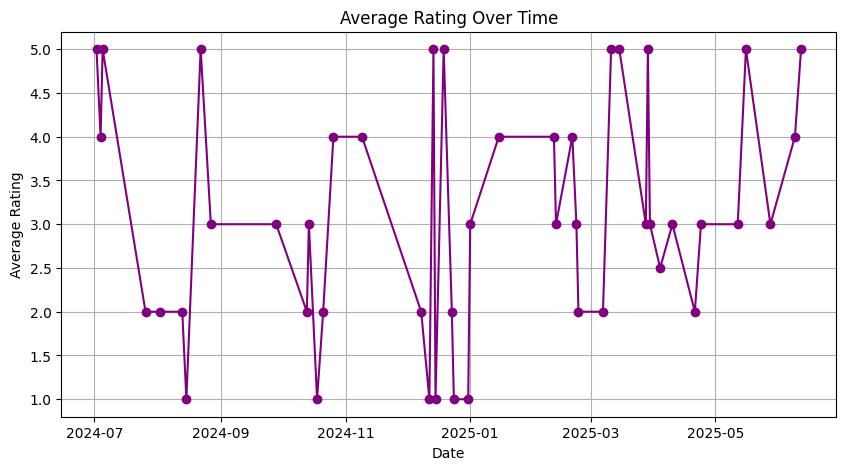

In [65]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

#Group by date and calculate average rating
rating_trend = df.groupby(df['date'].dt.date)['rating'].mean()

#Plot the trend 
plt.figure(figsize=(10,5))
rating_trend.plot(kind='line', marker='o', color='purple')
plt.title('Average Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()

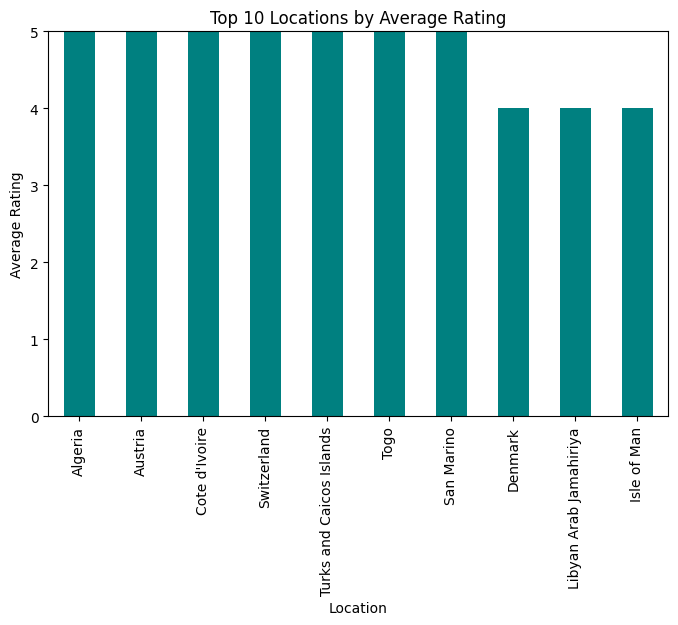

In [68]:
if 'location' in df.columns:
    #Group by location and calculate average rating
    location_ratings = df.groupby('location')['rating'].mean().sort_values(ascending=False).head(10)

    #Plot top 10 locations by average rating
    plt.figure(figsize=(8,5))
    location_ratings.plot(kind='bar', color='teal')
    plt.title('Top 10 Locations by Average Rating')
    plt.xlabel('Location')
    plt.ylabel('Average Rating')
    plt.ylim(0,5)
    plt.show()
else:
    print("'location' column not found in dataset.")    

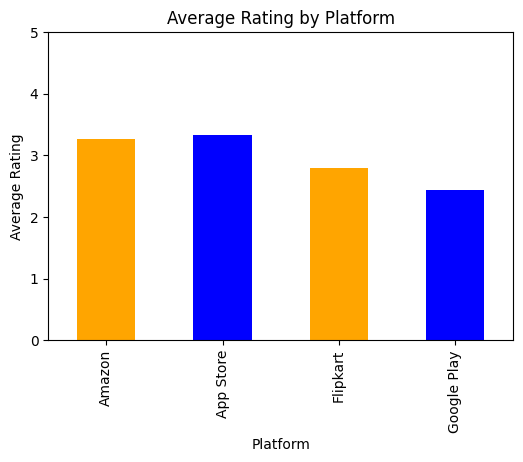

In [69]:
if 'platform' in df.columns:
    platform_ratings = df.groupby('platform')['rating'].mean()

    #Plot platform ratings
    plt.figure(figsize=(6,4))
    platform_ratings.plot(kind='bar', color=['orange','blue'])
    plt.title('Average Rating by Platform')
    plt.xlabel('Platform')
    plt.ylabel('Average Rating')
    plt.ylim(0,5)
    plt.show()
else:
    print("'platform' column not found in dataset.")
    
      

In [70]:
if 'verfied_purchase' in df.columns:
    verified_ratings = df.groupby('verfied_purchase')['rating'].mean()

    #PLot verified vs non-verified ratings
    plt.figure(figsize=(6,4))
    verified_ratings.plot(kind='bar', color=['green','red'])
    plt.title('Average Rating:Verified vs Non-Verified Users')
    plt.xlabel('Verified Purchase')
    plt.ylabel('Average Rating')
    plt.ylim(0,5)
    plt.show()
else:
    print("'verified_purchase' column not found in dataset.")



'verified_purchase' column not found in dataset.


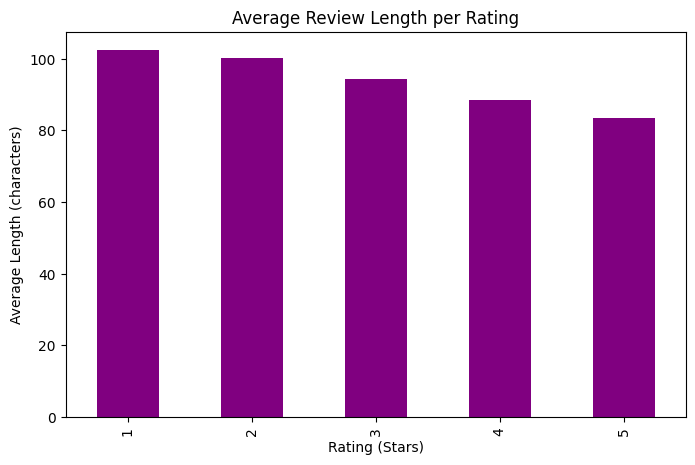

In [71]:
#Create a new column with review lengths
df['review_length'] = df['review'].astype(str).apply(len)

#Gruop by rating and calculate average review length 
avg_length = df.groupby('rating')['review_length'].mean()

# Plot
plt.figure(figsize=(8,5))
avg_length.plot(kind='bar', color='purple')
plt.title('Average Review Length per Rating')
plt.xlabel('Rating (Stars)')
plt.ylabel('Average Length (characters)')
plt.show()

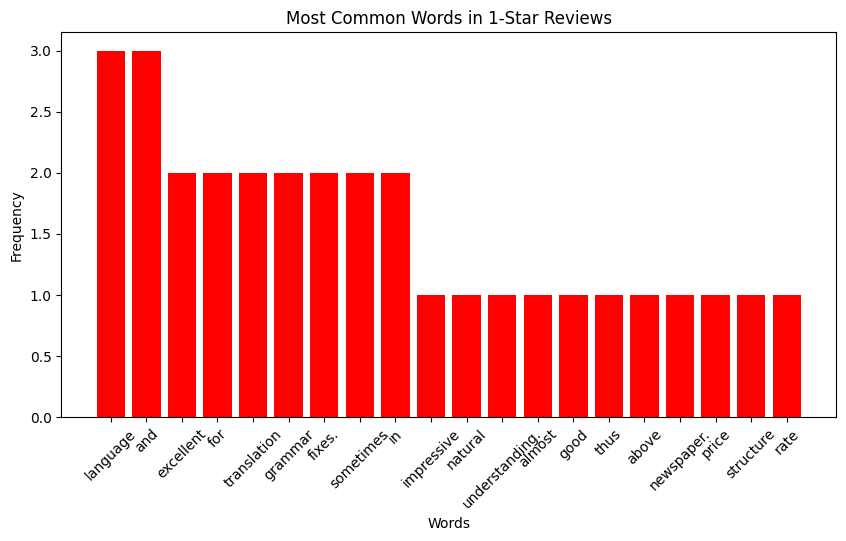

In [73]:
from collections import Counter

#Filter only 1-star reviews
one_star_reviews = df[df['rating'] == 1]['review']

#Join into one big string and split into words
words = " ".join(one_star_reviews.astype(str)).lower().split()

#Remove very short words (like "a", "I") for clarity
woeds = [w for w in words if len(w) > 2]

#Count most common words 
word_freq = Counter(words).most_common(20)

#Convert to DataFrame for plotting
word_df = pd.DataFrame(word_freq, columns=['word', 'count'])

#Plot bar chart
plt.figure(figsize=(10,5))
plt.bar(word_df['word'], word_df['count'], color='red')
plt.title('Most Common Words in 1-Star Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

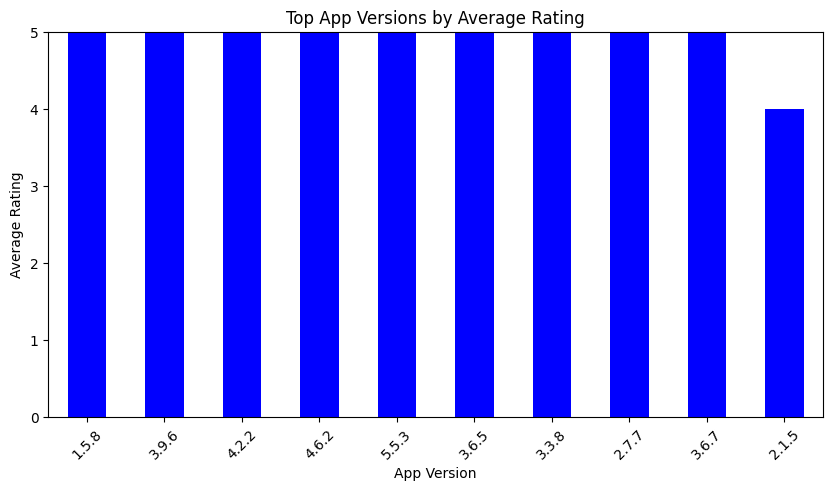

In [76]:
if 'version' in df.columns:
    #Group by version and calculate average rating
    version_ratings = df.groupby('version')['rating'].mean().sort_values(ascending=False)

    #Take top 10 versions
    top_versions = version_ratings.head(10)

    #Plot
    plt.figure(figsize=(10,5))
    top_versions.plot(kind='bar', color='blue')
    plt.title('Top App Versions by Average Rating')
    plt.xlabel('App Version')
    plt.ylabel('Average Rating')
    plt.ylim(0,5)
    plt.xticks(rotation=45)
    plt.show()
else:
    print("'version' column not found in dataset.")

In [86]:
# After predictions are added
df['sentiment'] = pipeline['model'].predict(pipeline['tfidf'].transform(df['review']))

# ✅ Ensure 'date' column exists
if 'date' not in df.columns:
    df['date'] = pd.NaT   # fill with missing if not available

# Save clean dataset for Streamlit
df[['review', 'rating', 'date', 'sentiment']].to_csv("final_data.csv", index=False)
print("✅ final_data.csv saved with columns:", df.columns.tolist())


✅ final_data.csv saved with columns: ['date', 'title', 'review', 'rating', 'username', 'helpful_votes', 'review_length', 'platform', 'language', 'location', 'version', 'verified_purchase', 'sentiment']
